In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


In [3]:
file_path = os.path.join("..", "data", "raw", "data.csv")
df = pd.read_csv(file_path, encoding='ISO-8859-1')

In [4]:
# Preview data
print("Shape:", df.shape)
display(df.head())

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
# Check data types and nulls
print("\nInfo:")
df.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## Cleaning and Processing

In [7]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [8]:
# Drop missing CustomerIDs (optional, but cleaner)
df.dropna(subset=['CustomerID'], inplace=True)

In [9]:
# Remove rows with negative Quantity or UnitPrice (likely returns or data errors)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [10]:
# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [11]:
# Create Month-Year column for grouping
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

In [12]:
# Group by Month to aggregate sales
monthly_sales = df.groupby('InvoiceMonth')['TotalPrice'].sum().reset_index()
monthly_sales['InvoiceMonth'] = monthly_sales['InvoiceMonth'].dt.to_timestamp()

display(monthly_sales.head())

,InvoiceMonth,TotalPrice
0,2010-12-01,572713.890
1,2011-01-01,569445.040
2,2011-02-01,447137.350
3,2011-03-01,595500.760
4,2011-04-01,469200.361


## Plotting Monthly Sales Trend

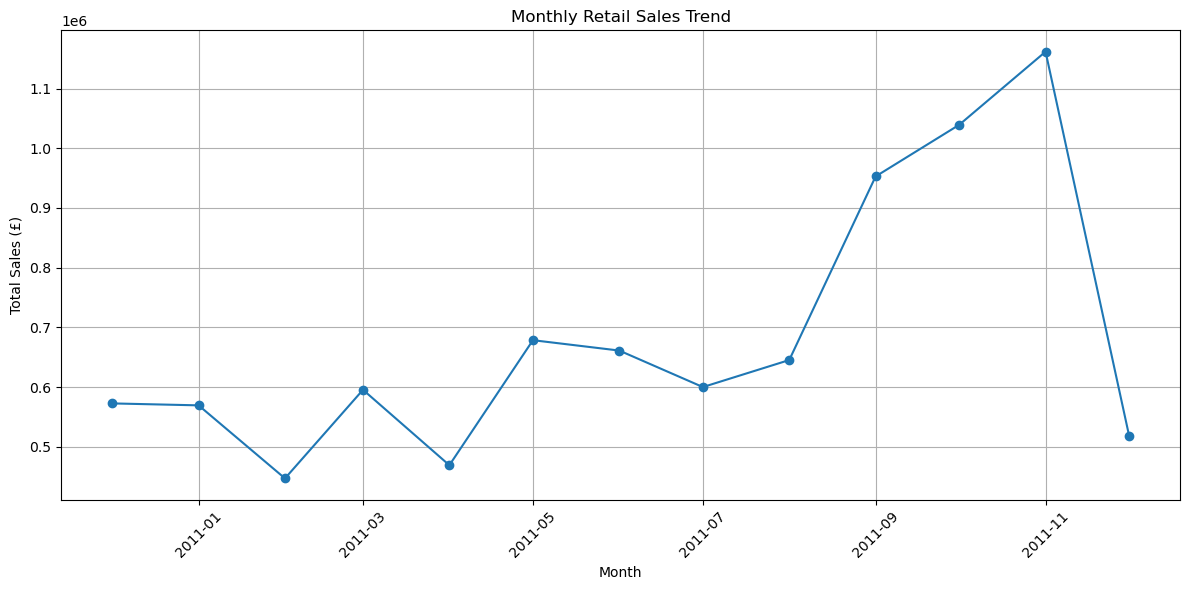

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['InvoiceMonth'], monthly_sales['TotalPrice'], marker='o')
plt.title('Monthly Retail Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (£)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Baseline forecast: last month's sales
last_month_sales = monthly_sales['TotalPrice'].iloc[-1]
print(f"Naive forecast for next month: £{last_month_sales:,.2f}")


Naive forecast for next month: £518,192.79


## Model Training & Forecasting:

In [15]:
# Set datetime index
ts = monthly_sales.set_index('InvoiceMonth')['TotalPrice']

# Fit ARIMA model (p,d,q can be tuned later)
model = ARIMA(ts, order=(1,1,1))  # ARIMA(p,d,q)
model_fit = model.fit()

# Forecast next 3 months
forecast = model_fit.forecast(steps=3)
print("\nForecasted sales for next 3 months:")
print(forecast)



Forecasted sales for next 3 months:
2012-01-01    640169.939158
2012-02-01    683621.667424
2012-03-01    699100.408339
Freq: MS, Name: predicted_mean, dtype: float64


C:\Users\vamshikrishna\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\vamshikrishna\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\vamshikrishna\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [16]:
# Compare last 3 actuals vs predictions (train-test split)
train = ts[:-3]
test = ts[-3:]

model = ARIMA(train, order=(1,1,1)).fit()
preds = model.forecast(steps=3)

mae = mean_absolute_error(test, preds)
rmse = np.sqrt(mean_squared_error(test, preds))

print(f"\nMAE: {mae:.2f} | RMSE: {rmse:.2f}")



MAE: 261237.26 | RMSE: 277666.97


C:\Users\vamshikrishna\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\vamshikrishna\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\vamshikrishna\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [17]:
pip install prophet


Note: you may need to restart the kernel to use updated packages.


In [18]:
from prophet import Prophet

# Prepare dataframe for Prophet
prophet_df = monthly_sales.rename(columns={"InvoiceMonth": "ds", "TotalPrice": "y"})

# Initialize and fit model
model = Prophet()
model.fit(prophet_df)


18:51:25 - cmdstanpy - INFO - Chain [1] start processing
18:51:25 - cmdstanpy - INFO - Chain [1] done processing


In [19]:
# Predict next 3 months
future = model.make_future_dataframe(periods=24, freq='M')
forecast = model.predict(future)

# View forecasted values
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)


C:\Users\vamshikrishna\anaconda3\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
34,2013-09-30,1.673463e+06,1.464317e+06,1.887788e+06
35,2013-10-31,1.709435e+06,1.497708e+06,1.919797e+06
36,2013-11-30,1.744247e+06,1.528364e+06,1.950550e+06


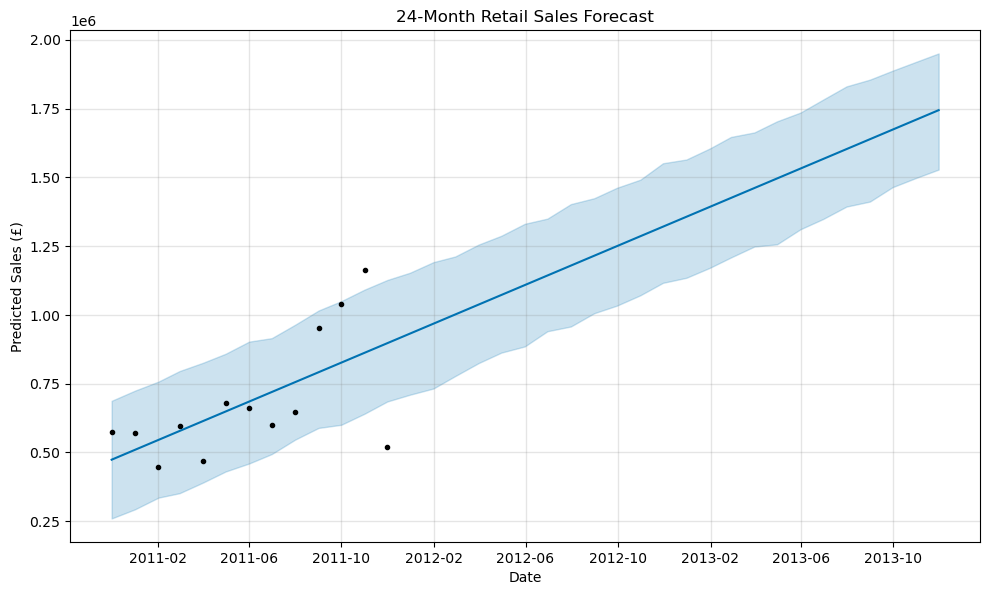

In [20]:
fig = model.plot(forecast)
plt.title("24-Month Retail Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales (£)")
plt.grid(True)
plt.show()


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual values for last 3 months
actual = monthly_sales['TotalPrice'].iloc[-3:].values


In [22]:
# ARIMA training on full data - forecast last 3
ts = monthly_sales.set_index('InvoiceMonth')['TotalPrice']
model_arima = ARIMA(ts[:-3], order=(1,1,1))
model_arima_fit = model_arima.fit()
arima_preds = model_arima_fit.forecast(steps=3).values


C:\Users\vamshikrishna\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\vamshikrishna\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\vamshikrishna\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [23]:
# Prophet forecasted all months; we extract the last 3 predictions
prophet_preds = forecast['yhat'].iloc[-3:].values


In [24]:
naive_pred = np.full(shape=3, fill_value=ts.iloc[-4])  # Use 4th last as prediction for next 3


In [25]:
def get_scores(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    return round(mae, 2), round(rmse, 2)

scores = {
    "Naive": get_scores(actual, naive_pred),
    "ARIMA": get_scores(actual, arima_preds),
    "Prophet": get_scores(actual, prophet_preds)
}

# Display scores
for model, (mae, rmse) in scores.items():
    print(f"{model} - MAE: £{mae}, RMSE: £{rmse}")


Naive - MAE: £243368.33, RMSE: £282882.7
ARIMA - MAE: £261237.26, RMSE: £277666.97
Prophet - MAE: £802605.38, RMSE: £857366.68


In [26]:
# Save the real aggregated monthly sales data to CSV
output_path = "./data/processed/monthly_sales.csv"

# Make sure directory exists
import os
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save file
monthly_sales.to_csv(output_path, index=False)
print(f"✅ File saved to: {output_path}")


✅ File saved to: ./data/processed/monthly_sales.csv


In [27]:
import os
os.getcwd()


'C:\\Users\\vamshikrishna\\Desktop\\New folder (2)\\retail_sales_forecasting\\notebooks'

In [28]:
pd.read_csv("./data/processed/monthly_sales.csv").head()


,InvoiceMonth,TotalPrice
0,2010-12-01,572713.890
1,2011-01-01,569445.040
2,2011-02-01,447137.350
3,2011-03-01,595500.760
4,2011-04-01,469200.361
